# 43 - CNN conf60 7-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "7class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 7
EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionImageDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 27
     fearful: 2
   disgusted: 13
   surprised: 16


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.2470     0.6552     1.0245    0.8135   0.1911   0.000100  (36.0s)


     2      0.6013     0.8634     0.7943    0.8152   0.1952   0.000100  (35.0s)


     3      0.4838     0.8665     0.7396    0.8273   0.1921   0.000100  (34.7s)


     4      0.4372     0.8704     0.7223    0.8100   0.1876   0.000100  (34.4s)


...

    26      0.1458     0.9510     0.8306    0.8273   0.2109   0.000050  (33.2s)


    27      0.1400     0.9535     0.7739    0.8152   0.2250   0.000050  (33.2s)


    28      0.1357     0.9552     0.8311    0.8256   0.2179   0.000050  (33.2s)


    29      0.1293     0.9578     0.8052    0.8290   0.2236   0.000050  (33.4s)


    30      0.1282     0.9593     0.8233    0.8238   0.2217   0.000050  (33.3s)

Early stopping at epoch 30. Best epoch: 15 (val_f1=0.2371)

Best: epoch 15, val_acc=0.8307, val_f1=0.2371
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/cnn_b1.pth


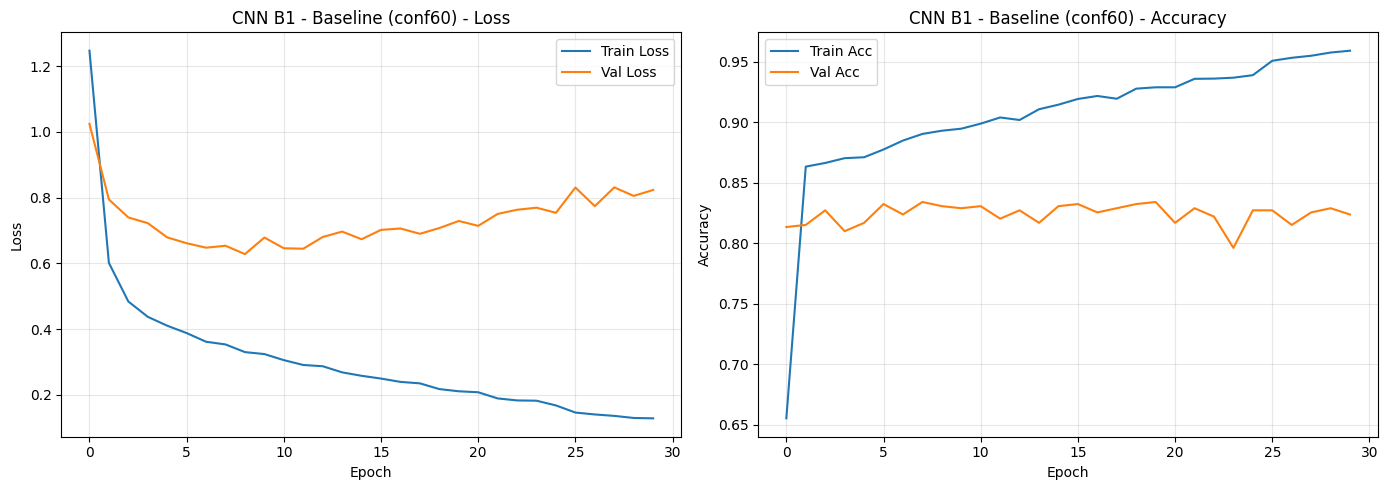

Test Loss: 0.5649
Test Accuracy: 0.8105
Test Macro F1: 0.2774
Test Weighted F1: 0.8092

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.88      0.89       688
       happy       0.63      0.72      0.67       183
         sad       0.39      0.38      0.38        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.81       929
   macro avg       0.27      0.28      0.28       929
weighted avg       0.81      0.81      0.81       929



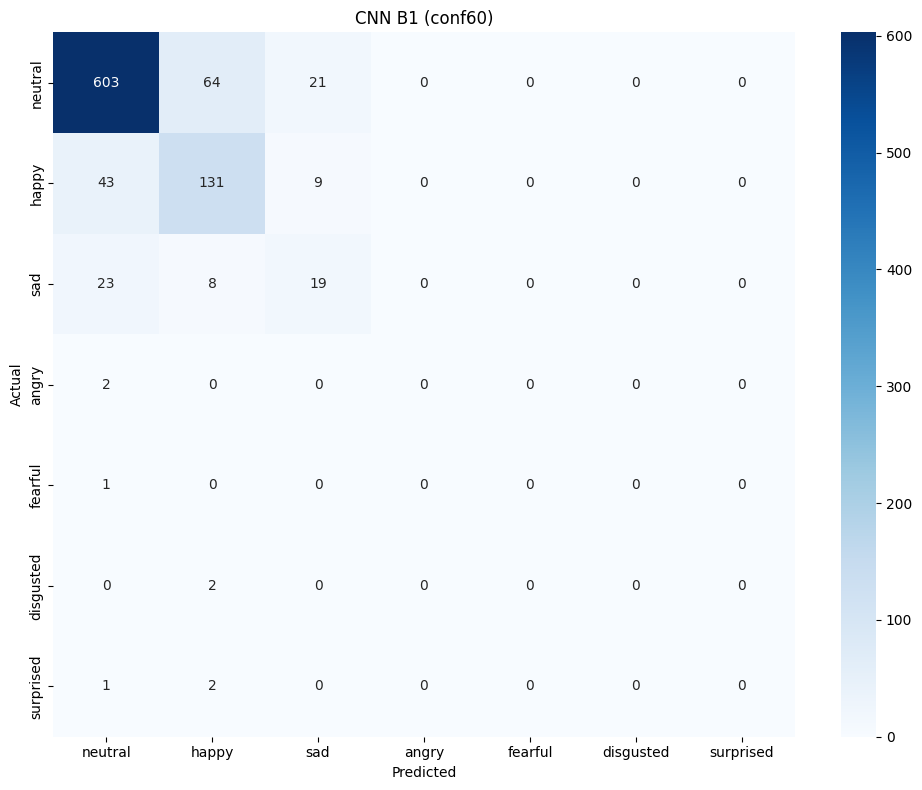

B1: Acc=0.8105 F1=0.2774

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1179     0.7080     1.0918    0.7945   0.1403   0.000100  (33.2s)


     2      0.5800     0.8615     0.8751    0.7461   0.1363   0.000100  (33.2s)


     3      0.4811     0.8619     0.8264    0.7271   0.1331   0.000100  (33.2s)


...

    28      0.1466     0.9512     0.8508    0.8117   0.2138   0.000050  (33.1s)


    29      0.1401     0.9527     0.8447    0.8100   0.2177   0.000050  (33.2s)


    30      0.1345     0.9556     0.8579    0.8117   0.2191   0.000050  (33.2s)


    31      0.1333     0.9540     0.8959    0.8152   0.2283   0.000050  (33.1s)


    32      0.1273     0.9571     0.8508    0.8117   0.2202   0.000050  (33.1s)

Early stopping at epoch 32. Best epoch: 17 (val_f1=0.2318)

Best: epoch 17, val_acc=0.8359, val_f1=0.2318
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/cnn_b2.pth


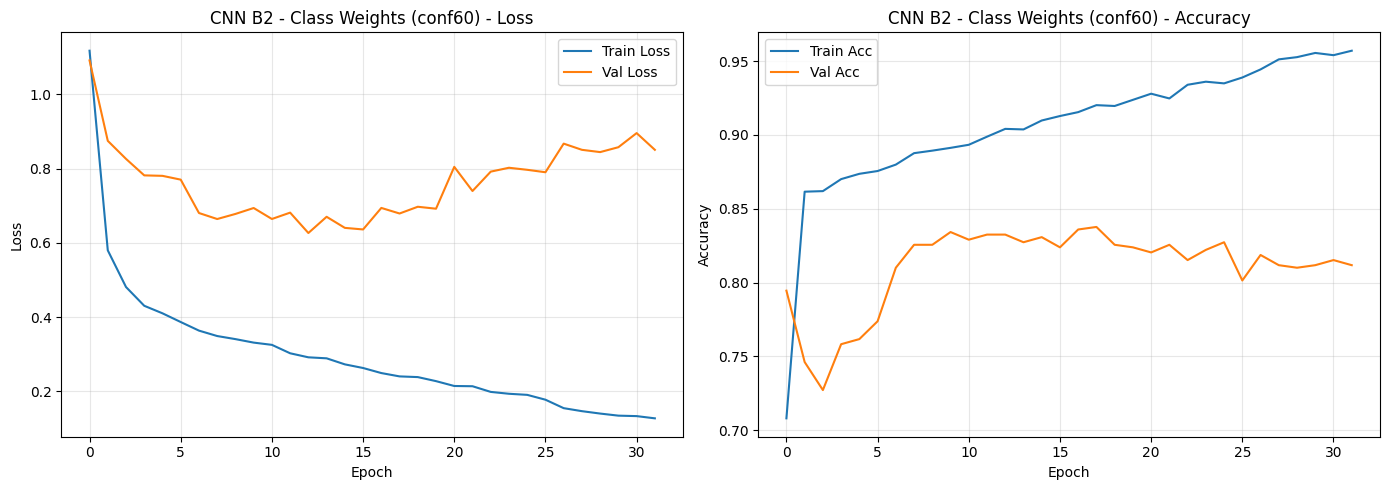

Test Loss: 0.5940
Test Accuracy: 0.7740
Test Macro F1: 0.2396
Test Weighted F1: 0.7666

Classification Report:
              precision    recall  f1-score   support

     neutral       0.85      0.88      0.87       688
       happy       0.58      0.56      0.57       183
         sad       0.27      0.22      0.24        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.77       929
   macro avg       0.24      0.24      0.24       929
weighted avg       0.76      0.77      0.77       929



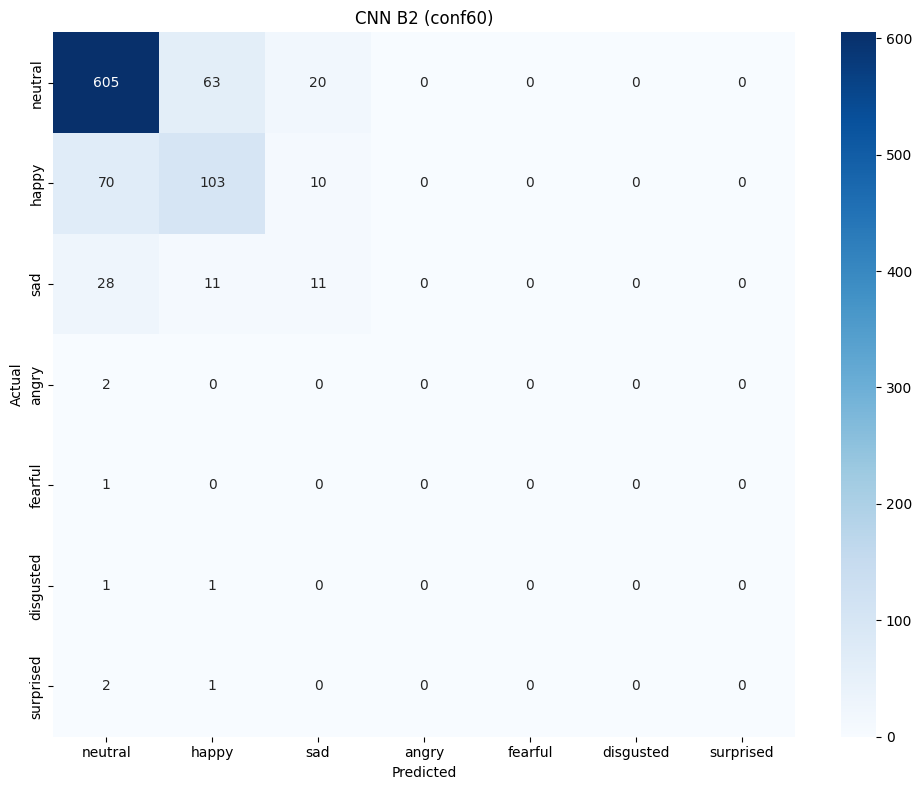

B2: Acc=0.7740 F1=0.2396


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.3599     0.5790     1.1163    0.8204   0.1289   0.000100  (37.2s)


     2      0.7900     0.7869     0.9248    0.8066   0.1423   0.000100  (37.9s)


...

    23      0.1685     0.9408     1.0287    0.7927   0.1827   0.000050  (37.7s)


    24      0.1556     0.9496     0.9915    0.7755   0.1848   0.000050  (37.4s)


    25      0.1492     0.9499     1.0434    0.7962   0.1826   0.000050  (37.5s)


    26      0.1453     0.9521     1.0873    0.7807   0.1829   0.000050  (37.4s)


    27      0.1373     0.9545     1.1045    0.7893   0.1929   0.000050  (37.4s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.2148)

Best: epoch 12, val_acc=0.8083, val_f1=0.2148
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/cnn_b3.pth


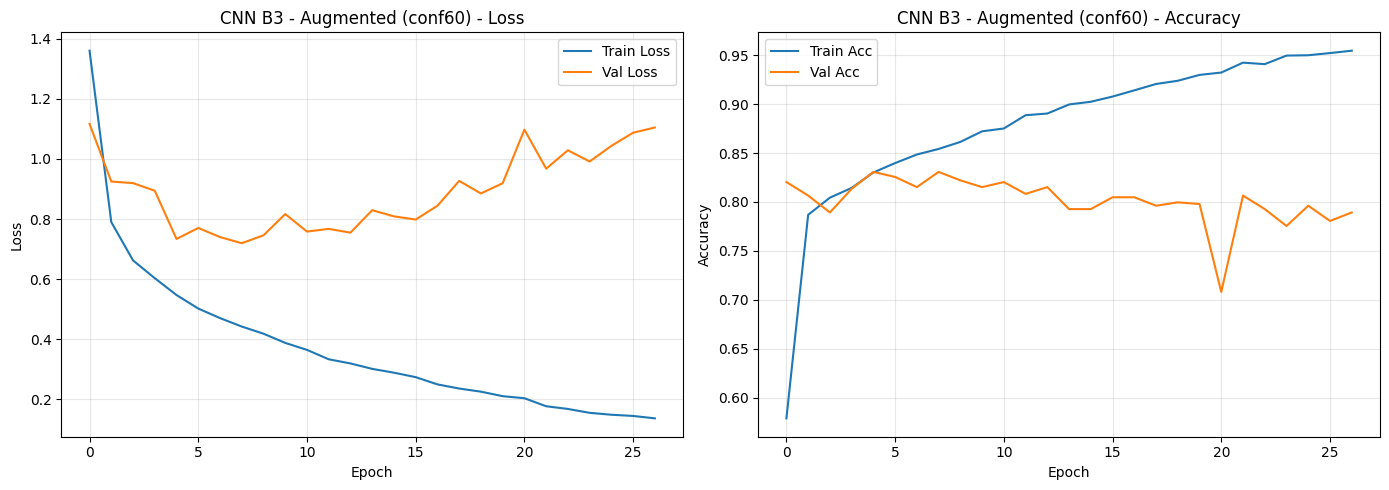

Test Loss: 0.6088
Test Accuracy: 0.7847
Test Macro F1: 0.2531
Test Weighted F1: 0.7820

Classification Report:
              precision    recall  f1-score   support

     neutral       0.87      0.87      0.87       688
       happy       0.61      0.64      0.63       183
         sad       0.37      0.22      0.28        50
       angry       0.00      0.00      0.00         2
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         2
   surprised       0.00      0.00      0.00         3

    accuracy                           0.78       929
   macro avg       0.26      0.25      0.25       929
weighted avg       0.78      0.78      0.78       929



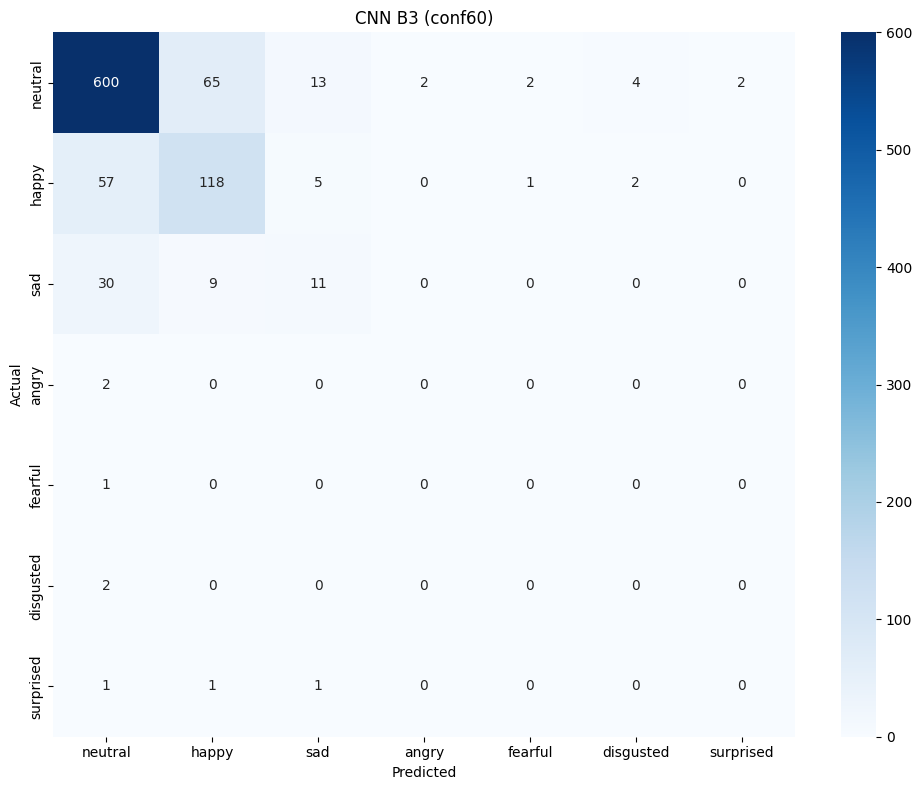

B3: Acc=0.7847 F1=0.2531

RINGKASAN CNN (conf60)
  B1 Baseline               Acc=0.8105 F1=0.2774
  B2 Class Weights          Acc=0.7740 F1=0.2396
  B3 Weights+Aug            Acc=0.7847 F1=0.2531

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/7class/cnn_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b1.pth"))
plot_training_history(history_b1, "CNN B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "CNN B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b2.pth"))
plot_training_history(history_b2, "CNN B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "CNN B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = EmotionCNN(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "cnn_b3.pth"))
plot_training_history(history_b3, "CNN B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "cnn", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "CNN B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN CNN (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "cnn_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'cnn_results.json'}")